# **Notebook 4**

#### Ian García
#### A01706892

**Mean Square Error (MSE)**

In [26]:
#Libraries

from sklearn.metrics import mean_squared_error
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# Dataset

diabetes = load_diabetes()
X = diabetes.data
y = diabetes.target

In [4]:
# Data split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [5]:
# Create models

models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(),
    'Random Forest': RandomForestRegressor(random_state=42)
}

In [6]:
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    print(f"{name} - MSE: {mse:.2f}")

Linear Regression - MSE: 2900.19
Ridge Regression - MSE: 3077.42
Random Forest - MSE: 2952.01


**Mean Absolute Error (MAE)**

In [7]:
from sklearn.metrics import mean_absolute_error
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
import numpy as np
import matplotlib.pyplot as plt

In [8]:
X = diabetes.data[:, np.newaxis, 2]
y = diabetes.target

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [10]:
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(),
    'Lasso Regression': Lasso(),
}

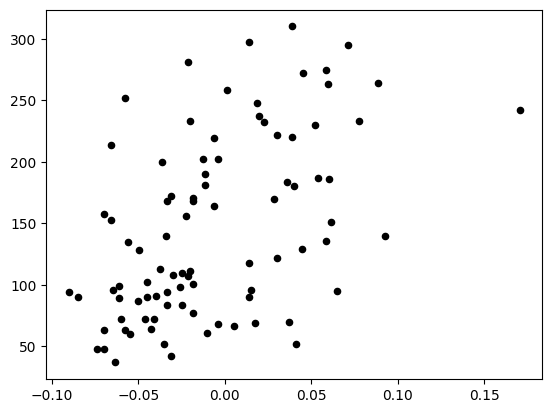

In [11]:
plt.scatter (X_test, y_test, color='black', s=20, marker='o', label='true values')

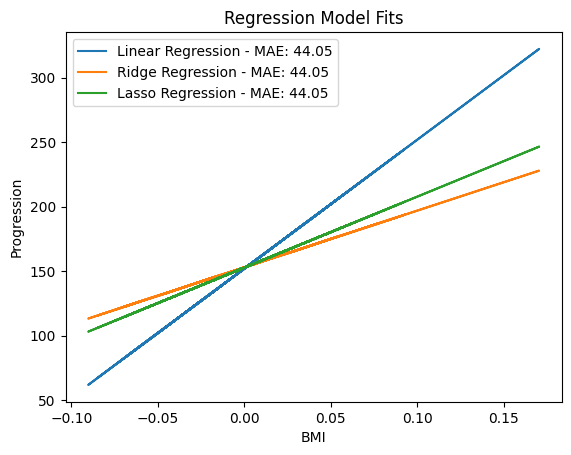

In [12]:
for name, model in models.items():
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    plt.plot(X_test, predictions, label=f'{name} - MAE: {mae:.2f}')

plt.xlabel ('BMI')
plt. ylabel ('Progression')
plt.title('Regression Model Fits')
plt.legend ()
plt.show()

**Root Mean Squared Error (RMSE)**

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [14]:
models = [
    ('Linear Regression', LinearRegression()),
    ('Decision Tree', DecisionTreeRegressor(random_state=42)),
    ('Random Forest', RandomForestRegressor(random_state=42))
]

In [15]:
rmse_scores = []

In [16]:
for name, model in models:
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    rmse_scores.append((name, rmse))
    print(f"{name} - RMSE: {rmse:.2f}")

Linear Regression - RMSE: 62.33
Decision Tree - RMSE: 68.98
Random Forest - RMSE: 66.05


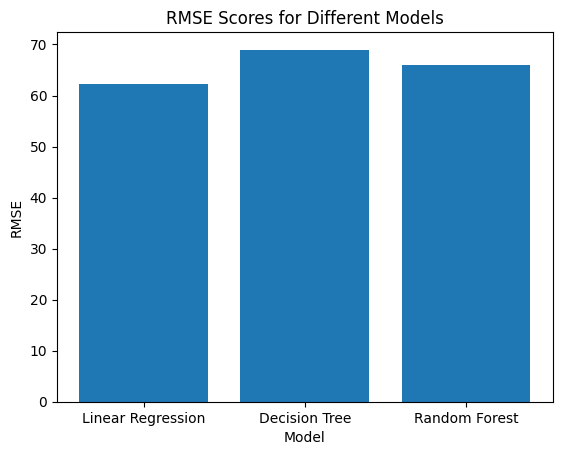

In [17]:
names, scores = zip(*rmse_scores)
plt.bar(names, scores)
plt.xlabel('Model')
plt.ylabel('RMSE')
plt.title('RMSE Scores for Different Models')
plt.show()

**Coefficient of Determination R2**

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [19]:
models = [
    ('Linear Regression', LinearRegression()),
    ('Decision Tree', DecisionTreeRegressor(random_state=42)),
    ('Random Forest', RandomForestRegressor(random_state=42))
]

In [20]:
r2_scores = []

In [21]:
for name, model in models:
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    r2 = model.score(X_test, y_test)
    r2_scores.append((name, r2))
    print(f"{name} - R2: {r2:.2f}")

Linear Regression - R2: 0.28
Decision Tree - R2: 0.12
Random Forest - R2: 0.19


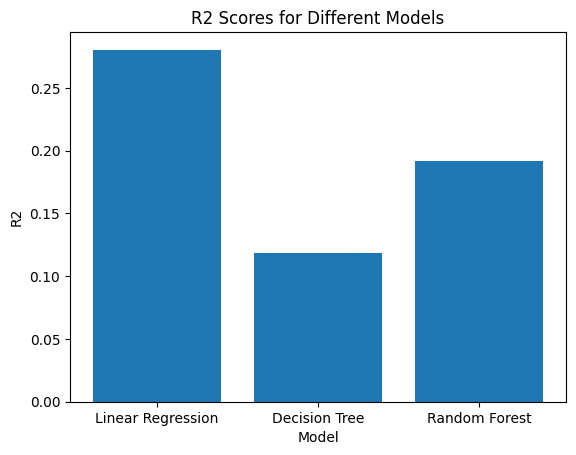

In [22]:
names, scores = zip(*r2_scores)
plt.bar(names, scores)
plt.xlabel('Model')
plt.ylabel('R2')
plt.title('R2 Scores for Different Models')
plt.show()

**Mean Absolute Percetnage Error (MAPE)**

In [23]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [24]:
# Define MAPE function

def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    non_zero_indices = y_true != 0 # Avoid division by zero
    return np.mean(np.abs((y_true[non_zero_indices] - y_pred[non_zero_indices]) / y_true[non_zero_indices])) * 100

In [27]:
# List of models to evaluate
models = [
    ('Linear Regression', LinearRegression()), # Instantiate LinearRegression
    ('Ridge', Ridge()),
    ('Lasso', Lasso()),
    ('Decision Tree', DecisionTreeRegressor()), # Instantiate DecisionTreeRegressor
    ('Random Forest', RandomForestRegressor(random_state=42)),
    ('SVR', SVR())
]

In [28]:
mape_scores = []

In [29]:
for name, model in models:
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    mape = mean_absolute_percentage_error(y_test, predictions)
    mape_scores.append((name, mape))

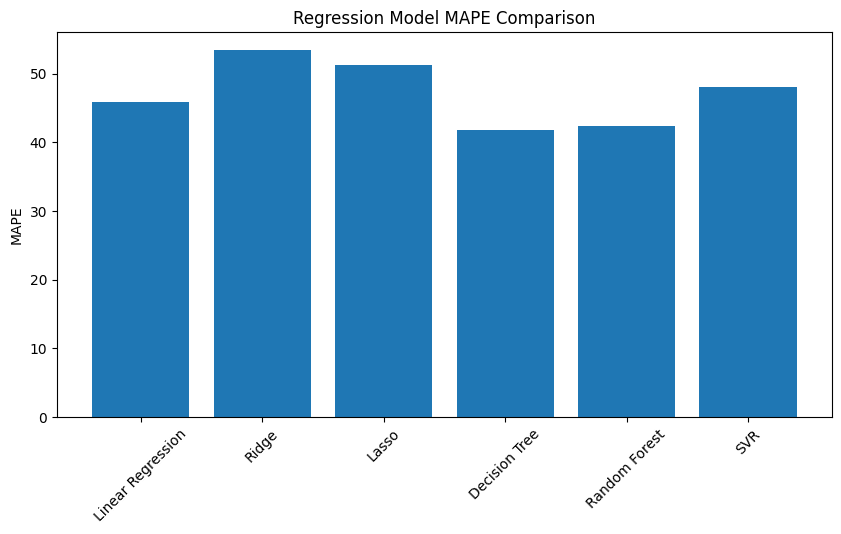

In [30]:
# Plotting
plt.figure(figsize = (10, 5))
names, mape_scores = zip(*mape_scores)
plt.bar(names, mape_scores)
plt.ylabel('MAPE')
plt.title('Regression Model MAPE Comparison')
plt.xticks(rotation = 45)
plt.show()